In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
img_size = 224
batch_size = 32
epochs = 15

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/brain_dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [6]:
val_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/Colab Notebooks/brain_dataset/train",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 50 images belonging to 2 classes.


In [7]:
model = models.Sequential([
    layers.Input(shape=(224,224,3)),

    layers.Conv2D(16,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(2,activation='softmax')
])

In [8]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [10]:
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6207 - loss: 0.6553 - val_accuracy: 0.6800 - val_loss: 0.5910
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7094 - loss: 0.5892 - val_accuracy: 0.6800 - val_loss: 0.5808
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6946 - loss: 0.5853 - val_accuracy: 0.6600 - val_loss: 0.6067
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6995 - loss: 0.5683 - val_accuracy: 0.7600 - val_loss: 0.5005
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7094 - loss: 0.5719 - val_accuracy: 0.7600 - val_loss: 0.5112
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7340 - loss: 0.5572 - val_accuracy: 0.7200 - val_loss: 0.5751
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7389 - loss: 0.5552 - val_accuracy: 0.7600 - val_loss: 0.4969
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7143 - loss: 0.5559 - val_accuracy: 0.7200 - val_loss: 0.5390
Epoch 9/15
7/

In [11]:
loss, accuracy = model.evaluate(val_generator)
print("Validation Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step - accuracy: 0.7600 - loss: 0.4816
Validation Accuracy: 0.7599999904632568


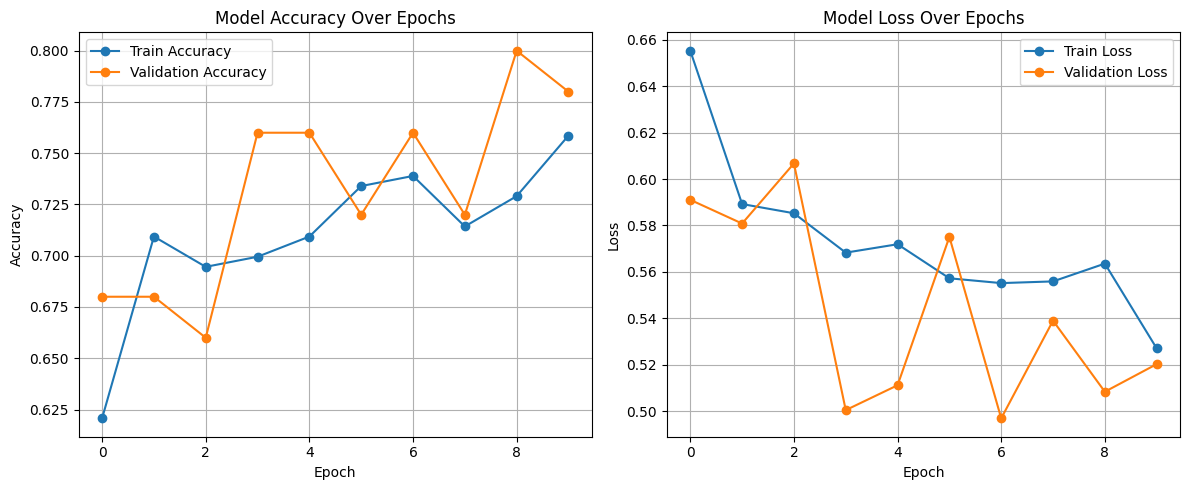

In [17]:

# Create figure
plt.figure(figsize=(12,5))

# -------- Accuracy Plot --------
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# -------- Loss Plot --------
plt.subplot(1,2,2)
plt.plot(history.history['loss'], marker='o', label='Train Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')

plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Layout adjustment
plt.tight_layout()

# Show plot
plt.show()